In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import numpy as np 
import pandas as pd 
import os

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, \
    OrdinalEncoder, PolynomialFeatures, TargetEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, RidgeCV, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

import xgboost as xgb
import lightgbm as lgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


In [4]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')
df_original = pd.read_csv('Exam_Score_Prediction.csv')

# EDA

In [5]:
overview = pd.DataFrame({
    "dtype": df_train.dtypes.astype(str),
    "missing": df_train.isna().sum(),
    "missing_%": (df_train.isna().mean() * 100).round(2),
    "nunique": df_train.nunique(dropna=False),
}).sort_values(["missing", "nunique"], ascending=False)

display(overview)
display(df_train.head(3))
print("Shape:", df_train.shape)
print("Duplicate rows:", df_train.duplicated().sum())

,dtype,missing,missing_%,nunique
id,int64,0,0.0,630000
exam_score,float64,0,0.0,805
study_hours,float64,0,0.0,792
class_attendance,float64,0,0.0,617
sleep_hours,float64,0,0.0,66
age,int64,0,0.0,8
course,str,0,0.0,7
study_method,str,0,0.0,5
gender,str,0,0.0,3
sleep_quality,str,0,0.0,3


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0


Shape: (630000, 13)
Duplicate rows: 0


## Data Sanity Checks

**Quick checks**
- Missingness: the overview table above shows **no missing values** across columns
- Duplicates: the printed count confirms that there are no duplicate rows in this dataset
- Types: dtypes look consistent with expectations (categorical, numeric, target)

**Notes**
- Since this dataset is clean, we can direct our attention for the rest of the EDA on distributions, imbalances, and feature-target relationships.

In [6]:
cat_var = ['gender', 'course', 'sleep_quality', 'study_method', 
           'facility_rating', 'exam_difficulty', 'internet_access']
num_var = ['age', 'study_hours', 'class_attendance', 'sleep_hours']
target = 'exam_score'

In [7]:
for c in cat_var:
    vc = df_train[c].value_counts(dropna=False).head(8)
    display(vc.to_frame("count").rename_axis(c))

,count
gender,
other,211097
male,210593
female,208310


,count
course,
b.tech,131236
b.sc,111554
b.com,110932
bca,88721
bba,75644
ba,61989
diploma,49924


,count
sleep_quality,
poor,213675
good,213089
average,203236


,count
study_method,
coaching,131697
self-study,131131
mixed,123086
group study,123009
online videos,121077


,count
facility_rating,
medium,214082
low,212378
high,203540


,count
exam_difficulty,
moderate,353982
easy,176540
hard,99478


,count
internet_access,
yes,579423
no,50577


In [8]:
course_notes = {
    "b.tech": "Bachelor of Technology",
    "b.sc": "Bachelor of Science",
    "bca": "Bachelor of Computer Applications",
    "diploma": "Diploma",
    "bba": "Bachelor of Business Administration",
    "b.com": "Bachelor of Commerce",
    "ba": "Bachelor of Arts"
}
display(pd.Series(course_notes, name="Meaning").rename_axis("course"))

course
b.tech                  Bachelor of Technology
b.sc                       Bachelor of Science
bca          Bachelor of Computer Applications
diploma                                Diploma
bba        Bachelor of Business Administration
b.com                     Bachelor of Commerce
ba                            Bachelor of Arts
Name: Meaning, dtype: str

## Categorical feature overview

**Observations**
- Mostly balanced across categories and within imbalances are never rare categories (likely won't affect model stability and evaluation too much)
- Some features may be **ordinal** (sleep_quality, facility_rating, exam_difficulty), while others are **nominal** (gender, course, study_method, internet_access)
- Course mapping above is included to make category values more readable

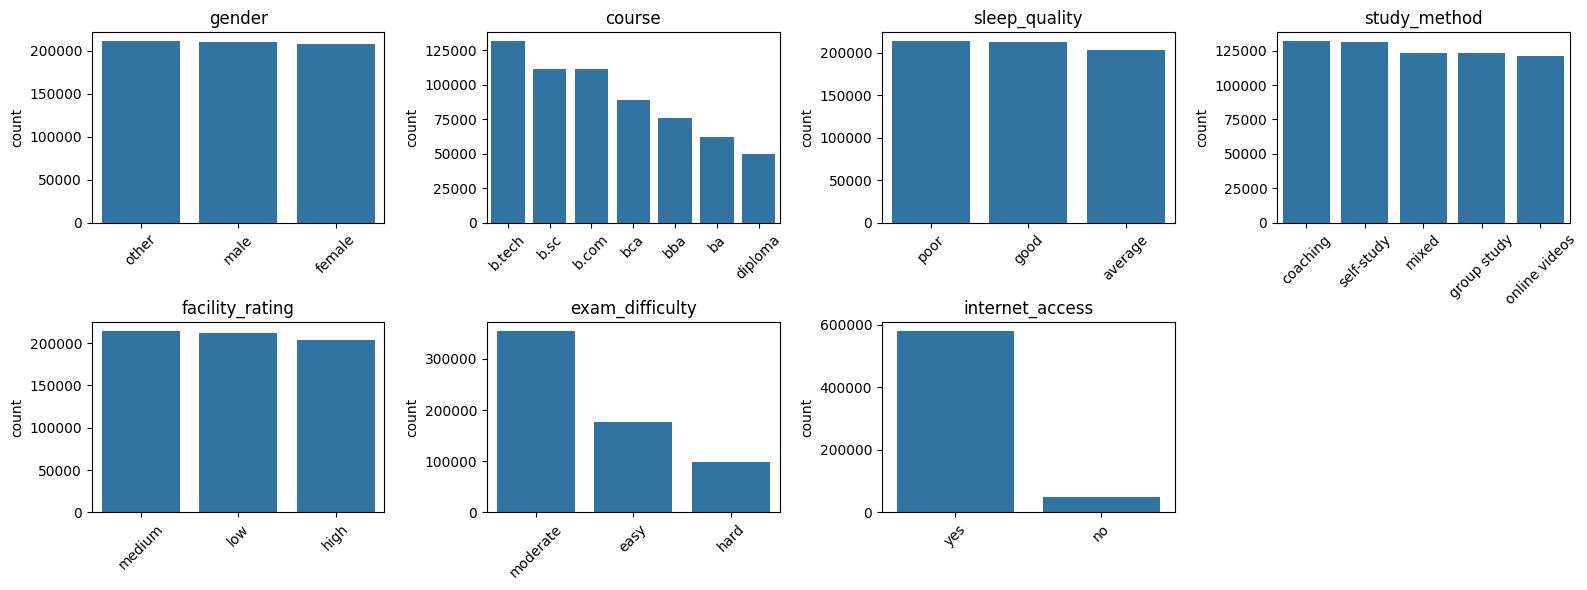

In [9]:
import math

n = len(cat_var)
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = np.array(axes).ravel()

for ax, c in zip(axes, cat_var):
    order = df_train[c].value_counts().index
    sns.countplot(data=df_train, x=c, order=order, ax=ax)
    ax.set_title(c)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(cat_var):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


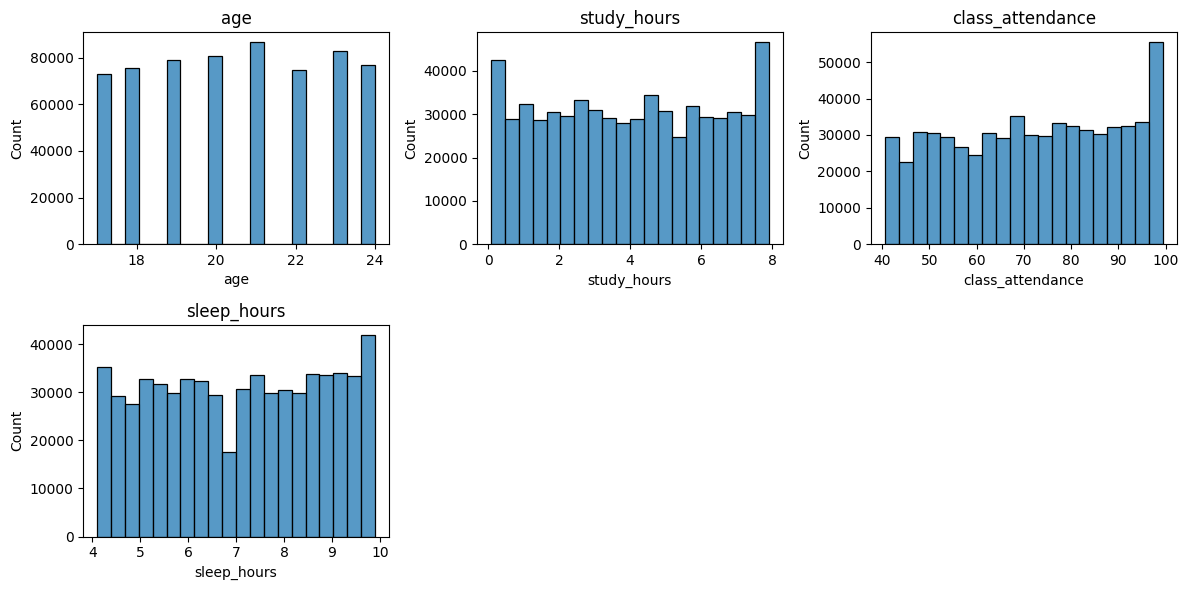

In [10]:
import math

n = len(num_var)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows))
axes = np.array(axes).ravel()

for ax, c in zip(axes, num_var):
    sns.histplot(df_train[c], bins=20, ax=ax)
    ax.set_title(c)
    ax.set_xlabel(c)

for ax in axes[len(num_var):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

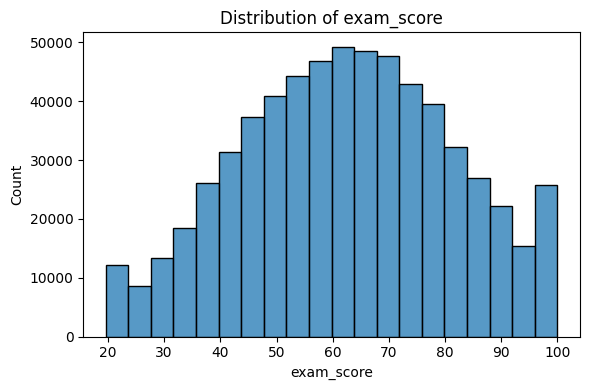

In [11]:
plt.figure(figsize=(6, 4))
sns.histplot(df_train[target], bins=20)
plt.title(f"Distribution of {target}")
plt.xlabel(target)
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [12]:
display(df_train[num_var + [target]].describe().T)

,count,mean,std,min,25%,50%,75%,max
age,630000.0,20.545821,2.260238,17.000,19.00,21.0,23.00,24.00
study_hours,630000.0,4.002337,2.359880,0.080,1.97,4.0,6.05,7.91
class_attendance,630000.0,71.987261,17.430098,40.600,57.00,72.6,87.20,99.40
sleep_hours,630000.0,7.072758,1.744811,4.100,5.60,7.1,8.60,9.90
exam_score,630000.0,62.506672,18.916884,19.599,48.80,62.6,76.30,100.00


## Feature-target relationships

To keep the notebook compact, I use summary plots to show:
- **Counts** (how common each value/range is), and
- **Target trend** (median exam_score) across categories or bins 

In [13]:
# plotting function

# note created with the help of chatgpt 5o
def plot_count_and_median(df, cols, target, bins=10, ncols=3, figsize=(5, 4),
                          int_as_cat_unique_max=20, cat_order=None):
    n = len(cols)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize[0]*ncols, figsize[1]*nrows))
    axes = np.array(axes).ravel()

    for i, col in enumerate(cols):
        ax = axes[i]
        tmp = df[[col, target]].dropna()
        if tmp.empty:
            ax.set_title(col)
            ax.axis("off")
            continue

        x = tmp[col]
        y = tmp[target]

        is_cat = (x.dtype == "object") or pd.api.types.is_string_dtype(x)

        # ---------- CATEGORICAL ----------
        if is_cat:
            counts = x.value_counts()
            med = tmp.groupby(col)[target].median()

            if cat_order is not None and col in cat_order:
                order = [v for v in cat_order[col] if v in counts.index]
                order += [v for v in sorted(counts.index) if v not in order]
            else:
                order = sorted(counts.index)

            counts = counts.loc[order]
            med = med.loc[order]

            xpos = np.arange(len(order))
            ax.bar(xpos, counts.values, zorder=1)
            ax.set_xticks(xpos)
            ax.set_xticklabels(order, rotation=45, ha="right")
            ax.set_title(col)
            ax.set_ylabel("Count")

            ax2 = ax.twinx()
            ax2.patch.set_visible(False)
            ax2.set_zorder(ax.get_zorder() + 1)
            ax2.plot(xpos, med.values, color="lightcoral", marker="o", linewidth=2, zorder=10)
            ax2.set_ylabel(f"Median {target}")

        # ---------- NUMERIC ----------
        else:
            xvals = x.to_numpy()
            yvals = y.to_numpy()

            # If numeric has low unique values (like age), treat as per-value bars
            uniq = np.sort(np.unique(xvals))
            if len(uniq) <= int_as_cat_unique_max:
                counts = np.array([(xvals == v).sum() for v in uniq])
                med = np.array([np.median(yvals[xvals == v]) for v in uniq])

                ax.bar(uniq, counts, zorder=1)
                ax.set_title(col)
                ax.set_xlabel(col)
                ax.set_ylabel("Count")

                ax2 = ax.twinx()
                ax2.patch.set_visible(False)
                ax2.set_zorder(ax.get_zorder() + 1)
                ax2.plot(uniq, med, color="lightcoral", marker="o", linewidth=2, zorder=10)
                ax2.set_ylabel(f"Median {target}")

            # Otherwise, regular histogram bins
            else:
                counts, edges = np.histogram(xvals, bins=bins)
                centers = (edges[:-1] + edges[1:]) / 2
                idx = np.digitize(xvals, edges) - 1

                med = np.array([
                    np.median(yvals[idx == j]) if np.any(idx == j) else np.nan
                    for j in range(len(centers))
                ])

                ax.bar(centers, counts, width=(edges[1] - edges[0]), zorder=1)
                ax.set_title(col)
                ax.set_xlabel(col)
                ax.set_ylabel("Count")

                ax2 = ax.twinx()
                ax2.patch.set_visible(False)
                ax2.set_zorder(ax.get_zorder() + 1)
                ax2.plot(centers, med, color="lightcoral", marker="o", linewidth=2, zorder=10)
                ax2.set_ylabel(f"Median {target}")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


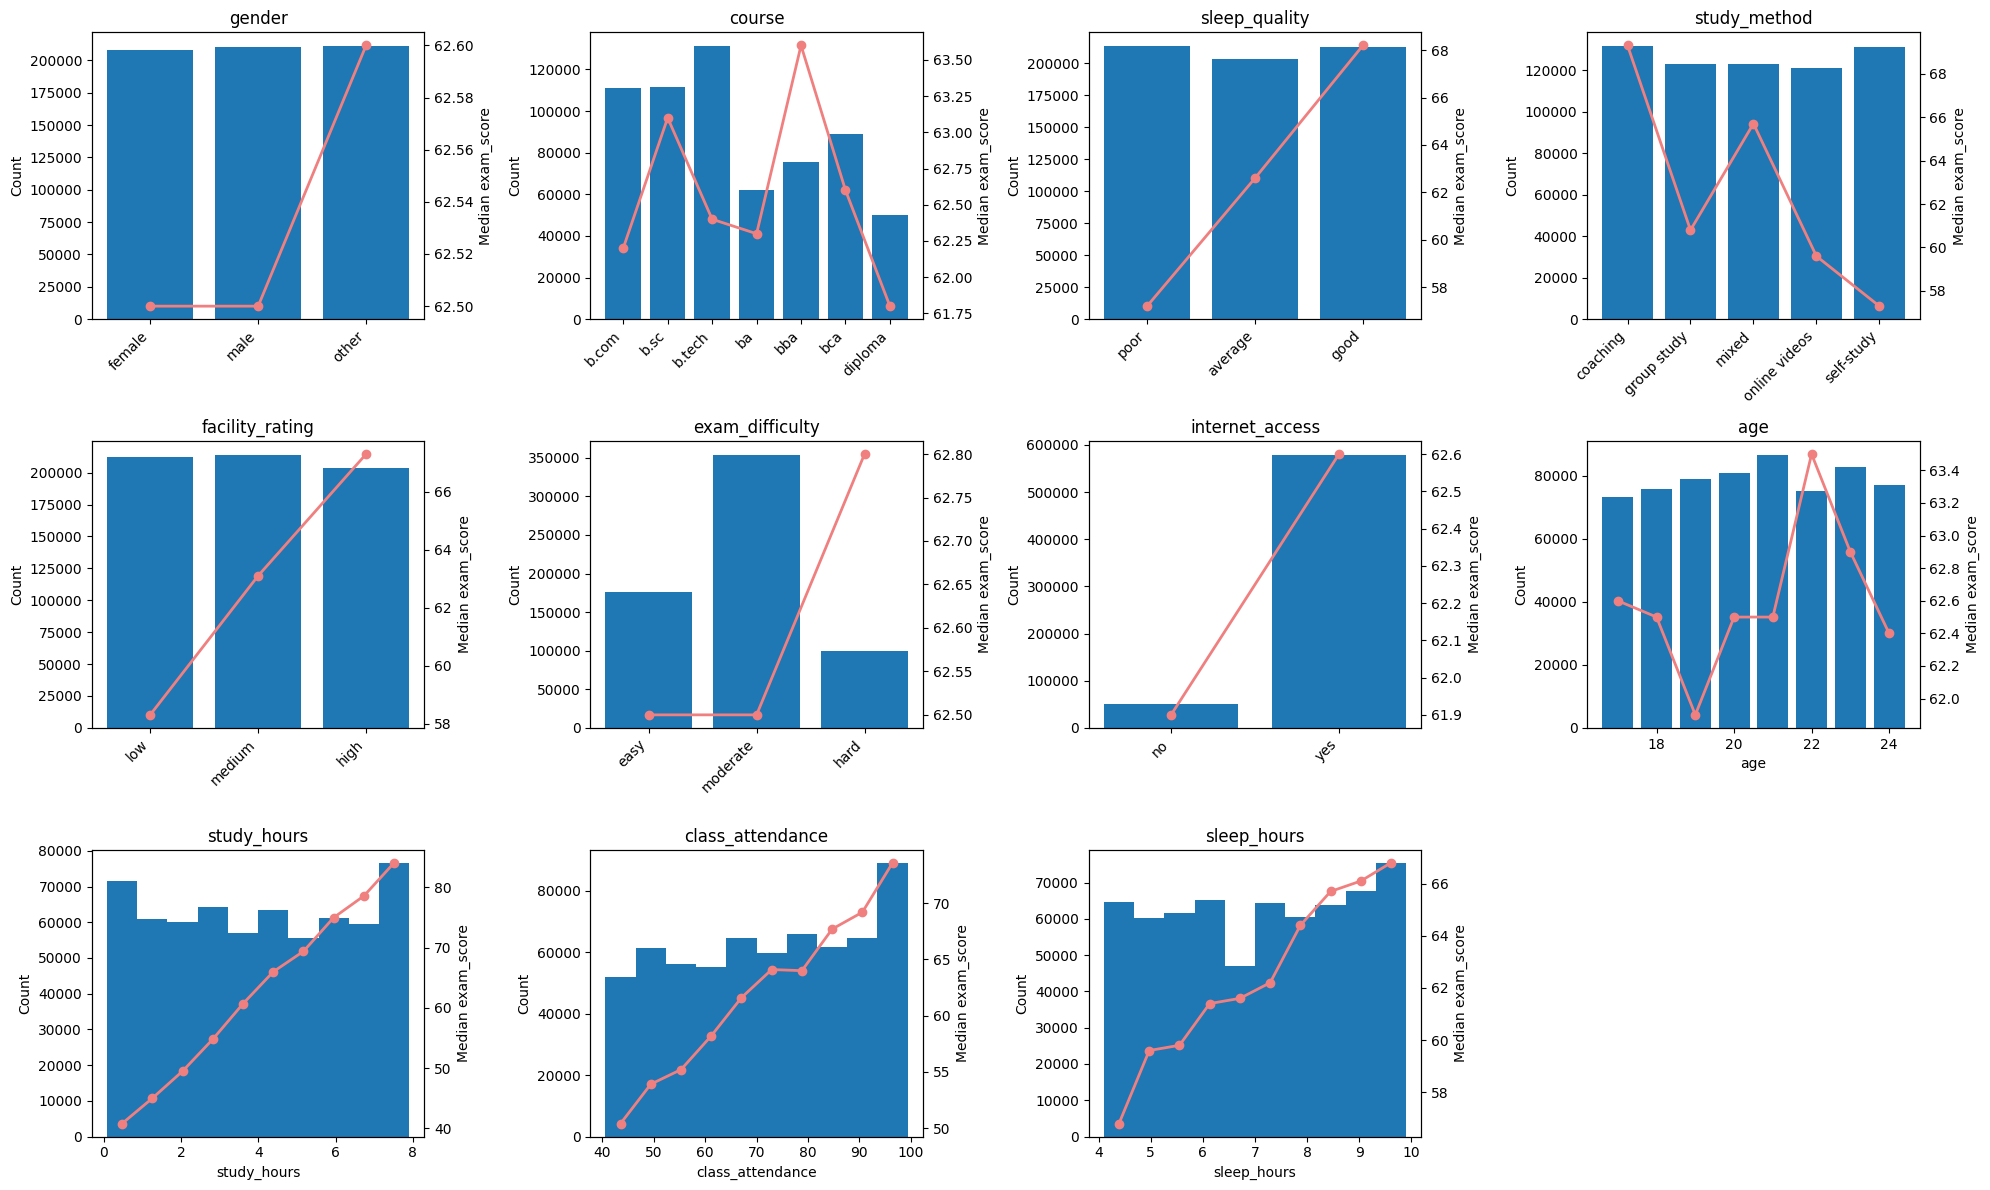

In [14]:
ordinal_order = {
    "sleep_quality": ["poor", "average", "good"],
    "facility_rating": ["low", "medium", "high"],
    "exam_difficulty": ["easy", "moderate", "hard"],
}

plot_count_and_median(df_train, cat_var + num_var, target, bins=10, ncols=4,
                      int_as_cat_unique_max=20, cat_order=ordinal_order)


### Key takeaways from the count + target-trend plots

**Strongest signals**
- The plots suggest that study behavior variables (e.g., study_hours, class_attendance, sleep_hours) have clear directional relationships with exam_score.

**Ordinal patterns**
- sleep_quality, facility_rating, and exam_difficulty appear to behave like **ordinal** variables (ordered levels correspond to consistent changes in exam_score).
- These are good candidates for **ordinal encoding** (using the explicit order), rather than one-hot encoding.

**Imbalance**
- internet_access appears imbalanced (one level occurs much more frequently). This is not necessarily an issue, but it’s worth keeping in mind for evaluation and interpretation.

**Nominal variables**
- course and study_method are best treated as **nominal** (no natural ranking). Any apparent “ordering” in the plot should not be interpreted as a true scale.


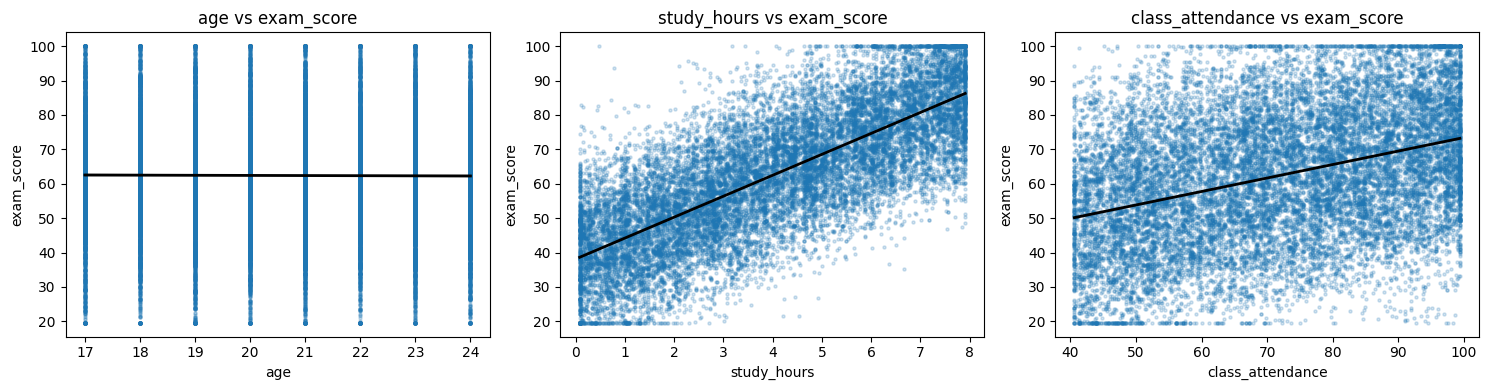

In [15]:
sample = df_train.sample(min(20000, len(df_train)), random_state=69)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))  
axes = np.array(axes).ravel()

for ax, feature in zip(axes, num_var[:3]): 
    sns.regplot(
        data=sample, x=feature, y=target, ax=ax,
        scatter_kws={"s": 5, "alpha": 0.2},
        line_kws={"linewidth": 2, "color": "black"}
    )
    ax.set_title(f"{feature} vs {target}")
    ax.set_xlabel(feature)
    ax.set_ylabel(target)

plt.tight_layout()
plt.show()


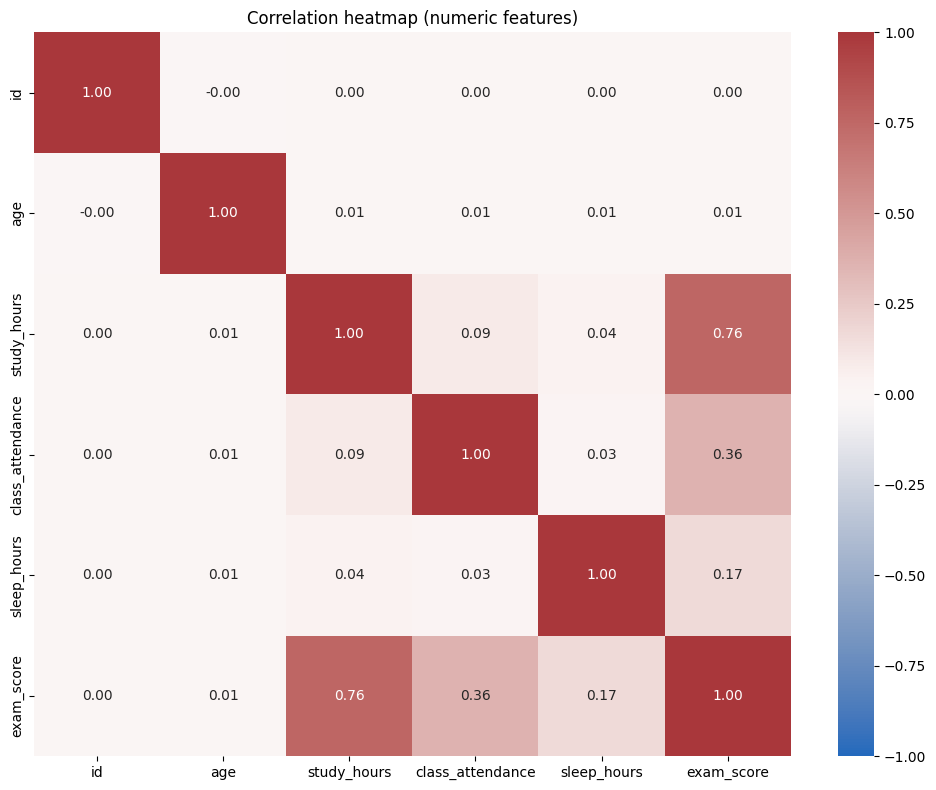

In [16]:
corr = df_train.select_dtypes("number").corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", vmin=-1, vmax=1, cmap="vlag", center=0)
plt.title("Correlation heatmap (numeric features)")
plt.tight_layout()
plt.show()

## EDA summary and modeling implications

**Data quality**
- Dataset appears clean (no missing/duplicates checked above)

**Predictiveness**
- Study behavior features (study_hours, class_attendance, sleep_hours) show the clearest relationships with exam_score
- Additional ordinal variables also show consistent directional effect

**Encoding plan**
- Treat as **ordinal** (ordered encoding): sleep_quality, facility_rating, exam_difficulty.
- Treat as **nominal** (no inherent order): gender, course, study_method, internet_access.

**Next steps**
- Move into feature engineering/encoding using the above decisions.
- Establish baseline models and compare performance using a consistent cross-validation setup.

# Feature Engineering

### Treating Continuous Features as Categorical for XGBoost

Four base numeric features — `age`, `study_hours`, `class_attendance`, and `sleep_hours` — are cast to `category` dtype before being passed to XGBoost, even though engineered float versions of the same features are also included.

This comes down to how XGBoost splits features. In `hist` mode (its default), XGBoost bins continuous values and makes threshold splits (e.g. "study_hours < 4.0"). When a feature is marked as `category`, XGBoost instead uses a categorical split algorithm that groups distinct values by gradient statistics — essentially an exhaustive partition search over the actual observed values rather than a simple threshold.

For features like `study_hours` (792 unique values) or `class_attendance` (617 unique values), this matters because the relationship with exam score may not be cleanly monotone — students at specific hour counts can cluster together in ways a threshold split misses.

Crucially, this does **not** replace the engineered versions. Both representations exist simultaneously:
- The **categorical version** lets XGBoost find non-monotone, value-specific patterns in the raw feature
- The **engineered float versions** (`study_hours_squared`, `log_study_hours`, `sqrt_study_hours`, bins, etc.) let XGBoost find smooth, monotone relationships via threshold splits

This dual representation is why including the 4 base numerics in `cat_cols` improves RMSE — XGBoost gets two complementary views of each feature rather than just one.

In [17]:
df_train["course"] = df_train["course"].map(course_notes)
df_test["course"] = df_test["course"].map(course_notes)

In [18]:
print(f"\n{'-'*80}")
print("FEATURE ENGINEERING START")
print(f"\n{'-'*80}")

def transform_cat_cols(df):

    df_temp = df.copy()

    for c in cat_var:
        df_temp[c] = df_temp[c].astype('category')

    # Ordinal variables
    df_temp['internet_access_numeric'] = (df_temp['internet_access'] == 'yes').astype(int)
    df_temp['sleep_quality_numeric'] = df_temp['sleep_quality'].map({'poor': 0, 'average': 1, 'good': 2}).astype(float)
    df_temp['facility_rating_numeric'] = df_temp['facility_rating'].map({'low': 0, 'medium': 1, 'high': 2}).astype(float)
    df_temp['exam_difficulty_numeric'] = df_temp['exam_difficulty'].map({'easy': 0, 'moderate': 1, 'hard': 2}).astype(float)

    return df_temp

def numeric_col_transformation(df):

    df_temp = df.copy()
    eps = 1e-6

    # Simple polynomials (2nd order only)
    df_temp['study_hours_squared'] = df_temp['study_hours'] ** 2
    df_temp['class_attendance_squared'] = df_temp['class_attendance'] ** 2
    df_temp['sleep_hours_squared'] = df_temp['sleep_hours'] ** 2

    # Log transforms
    sh_pos = df_temp['study_hours'].clip(lower=0)
    ca_pos = df_temp['class_attendance'].clip(lower=0)
    sl_pos = df_temp['sleep_hours'].clip(lower=0)

    df_temp['log_study_hours'] = np.log1p(sh_pos)
    df_temp['log_class_attendance'] = np.log1p(ca_pos)
    df_temp['log_sleep_hours'] = np.log1p(sl_pos)

    # Sqrt transforms
    df_temp['sqrt_study_hours'] = np.sqrt(sh_pos)
    df_temp['sqrt_class_attendance'] = np.sqrt(ca_pos)
    df_temp["sqrt_sleep_hours"] = np.sqrt(sl_pos)

    # Key interactions
    df_temp['study_hours_times_attendance'] = df_temp['study_hours'] * df_temp['class_attendance']
    df_temp['study_hours_times_sleep'] = df_temp['study_hours'] * df_temp['sleep_hours']
    df_temp['attendance_times_sleep'] = df_temp['class_attendance'] * df_temp['sleep_hours']

    # Important ratios
    df_temp['study_hours_over_sleep'] = df_temp['study_hours'] / (df_temp['sleep_hours'] + eps)
    df_temp['attendance_over_sleep'] = df_temp['class_attendance'] / (df_temp['sleep_hours'] + eps)
    df_temp['attendance_over_study'] = df_temp['class_attendance'] / (df_temp['study_hours'] + eps)

    # Ordinal × numeric interactions
    df_temp['study_hours_times_sleep_quality'] = df_temp['study_hours'] * df_temp['sleep_quality_numeric']
    df_temp['attendance_times_facility'] = df_temp['class_attendance'] * df_temp['facility_rating_numeric']
    df_temp['sleep_hours_times_difficulty'] = df_temp['sleep_hours'] * df_temp['exam_difficulty_numeric']

    # Ordinal × ordinal interactions
    df_temp['facility_times_sleepq'] = df_temp['facility_rating_numeric'] * df_temp['sleep_quality_numeric']
    df_temp['difficulty_times_facility'] = df_temp['exam_difficulty_numeric'] * df_temp['facility_rating_numeric']

    # Rule-based flags
    df_temp["high_att_high_study"] = ((df_temp["class_attendance"] >= 90) & (df_temp["study_hours"] >= 6)).astype(int)
    df_temp["ideal_sleep_flag"] = ((df_temp["sleep_hours"] >= 7) & (df_temp["sleep_hours"] <= 9)).astype(int)
    df_temp["high_study_flag"] = (df_temp["study_hours"] >= 7).astype(int)

    # Composite efficiency
    df_temp['efficiency'] = (df_temp['study_hours'] * df_temp['class_attendance']) / (df_temp['sleep_hours'] + 1)

    # Binned features
    df_temp["age_bin_num"] = pd.cut(df_temp["age"], bins=[0,17,19,21,23,100], labels=[0,1,2,3,4]).astype(float)
    df_temp["study_bin_num"] = pd.cut(df_temp["study_hours"], bins=[-1,2,4,6,8,100], labels=[0,1,2,3,4]).astype(float)
    df_temp["sleep_bin_num"] = pd.cut(df_temp["sleep_hours"], bins=[-1,5,6,7,8,100], labels=[0,1,2,3,4]).astype(float)
    df_temp["attendance_bin_num"] = pd.cut(df_temp["class_attendance"], bins=[-1,60,75,85,95,101], labels=[0,1,2,3,4]).astype(float)

    # Gap features
    df_temp['sleep_gap_8'] = (df_temp['sleep_hours'] - 8.0).abs()
    df_temp['attendance_gap_100'] = (df_temp['class_attendance'] - 100.0).abs()

    df_temp["age_squared"] = df_temp["age"] ** 2
    df_temp["age_times_study_hours"] = df_temp["age"] * df_temp["study_hours"]
    
    new_cols = ['study_hours_squared', 'class_attendance_squared', \
               'sleep_hours_squared', 'log_study_hours', 'log_class_attendance', \
               'log_sleep_hours', 'sqrt_study_hours', 'sqrt_class_attendance', \
               "sqrt_sleep_hours", 'study_hours_times_attendance', 'study_hours_times_sleep', \
               'attendance_times_sleep', 'study_hours_over_sleep', 'attendance_over_sleep', \
               'attendance_over_study', 'study_hours_times_sleep_quality', \
               'attendance_times_facility', 'sleep_hours_times_difficulty', \
               'facility_times_sleepq', 'difficulty_times_facility', \
               "high_att_high_study", "ideal_sleep_flag", "high_study_flag", \
               'efficiency', "age_bin_num", "study_bin_num", "sleep_bin_num", \
               "attendance_bin_num", 'sleep_gap_8', 'attendance_gap_100', \
               "age_squared", "age_times_study_hours"]

    return df_temp, new_cols

X_raw = df_train.drop(columns=['id', target])
y = df_train[target]

print(f"Original Base feature count: {len(X_raw.columns)}")

X = transform_cat_cols(X_raw)
print(f"Columns after categorical transform: {len(X.columns)}")
X, new_cols = numeric_col_transformation(X)

X_test = transform_cat_cols(df_test)
X_test, _ = numeric_col_transformation(X_test)

X_orig = transform_cat_cols(df_original)
X_orig, _ = numeric_col_transformation(X_orig)

X_test = X_test.reindex(columns=X.columns, fill_value=0)
X_orig = X_orig.reindex(columns=X.columns, fill_value=0)
y_orig = df_original[target]

print(f"Engineered numeric features: {len(new_cols)}")
print(f"Total features: {X.shape[1]}")



--------------------------------------------------------------------------------
FEATURE ENGINEERING START

--------------------------------------------------------------------------------
Original Base feature count: 11
Columns after categorical transform: 15
Engineered numeric features: 32
Total features: 47


# MODELING

## Baselines

### Baseline RMSEs:

**A lot more FE**: \
Linear Regression: 8.883910 \
XGBM: 8.818511 \
LightGBM: 8.830909

Given that FE works better with regression only, maybe for final model we use only categorical features + ridge predictions

**Categorical transformation**: \
Linear Regression: 8.895366 \
XGBM: 8.806594 \
LightGBM: 8.811549

**Regular OHE**: \
Linear Regression: 8.895558 \
XGBM: 8.820857 \
LightGBM: 8.813227

In [19]:
X_base = X.copy()
X_base = pd.get_dummies(X_base, columns=[cat for cat in cat_var])

In [20]:
# # Linear Regression

# kf = KFold(n_splits=10, shuffle=True, random_state=69)

# oof = np.zeros(len(X))

# X_base = X_base.copy()

# for fold, (tr_idx, va_idx) in enumerate(kf.split(X_base, y), 1):
#     X_tr, y_tr = X_base.iloc[tr_idx].copy(), y.iloc[tr_idx]
#     X_va, y_va = X_base.iloc[va_idx].copy(), y.iloc[va_idx]

#     # train model
#     curr_model = LinearRegression()
#     curr_model.fit(X_tr, y_tr)

#     # predict and validate scores
#     oof[va_idx] = curr_model.predict(X_va)

#     fold_rmse = np.sqrt(mean_squared_error(y_va, oof[va_idx]))
#     print(f"Fold {fold} RMSE: {fold_rmse:.4f}")

# rmse = np.sqrt(mean_squared_error(y, oof))
# print("OOF RMSE:", rmse)


# # FINAL FIT ON ALL DATA
# # X_all = X.copy()

# # feat_names = X_all.columns.to_numpy()
# # coefs = curr_model.coef_

# # coeff_df = pd.DataFrame({'feature': feat_names, "coef": coefs})
# # top = coeff_df.nlargest(10, "coef").sort_values("coef", ascending=True)
# # bottom = coeff_df.nsmallest(10, "coef")
# # show = pd.concat([bottom, top], axis=0)

# # plt.figure()
# # plt.barh(show["feature"], np.log(show["coef"]))
# # plt.axvline(0)
# # plt.xlabel("Importance (log gain)")
# # plt.ylabel("top and bottom 10 features")
# # plt.tight_layout()
# # plt.show()


In [21]:
# # XGBM

# kf = KFold(n_splits=10, shuffle=True, random_state=69)

# oof = np.zeros(len(X))

# X_base = X_base.copy()

# for fold, (tr_idx, va_idx) in enumerate(kf.split(X_base, y), 1):
#     X_tr, y_tr = X_base.iloc[tr_idx].copy(), y.iloc[tr_idx]
#     X_va, y_va = X_base.iloc[va_idx].copy(), y.iloc[va_idx]

#     # train model
#     curr_model = XGBRegressor(random_state=69)
#     curr_model.fit(X_tr, y_tr)

#     # predict and validate scores
#     oof[va_idx] = curr_model.predict(X_va)

#     fold_rmse = np.sqrt(mean_squared_error(y_va, oof[va_idx]))
#     print(f"Fold {fold} RMSE: {fold_rmse:.4f}")

# rmse = np.sqrt(mean_squared_error(y, oof))
# print("OOF RMSE:", rmse)


# # FINAL FIT ON ALL DATA
# # X_all = X.copy()

# # feat_names = X_all.columns.to_numpy()
# # coefs = curr_model.feature_importances_

# # coeff_df = pd.DataFrame({'feature': feat_names, "coef": coefs})
# # top = coeff_df.nlargest(10, "coef").sort_values("coef", ascending=True)
# # bottom = coeff_df.nsmallest(10, "coef")
# # show = pd.concat([bottom, top], axis=0)

# # plt.figure()
# # plt.barh(show["feature"], np.log(show["coef"]))
# # plt.axvline(0)
# # plt.xlabel("Importance (log gain)")
# # plt.ylabel("top and bottom 10 features")
# # plt.tight_layout()
# # plt.show()


In [22]:
# # Light GBM

# kf = KFold(n_splits=10, shuffle=True, random_state=69)

# oof = np.zeros(len(X))

# X_base = X_base.copy()

# for fold, (tr_idx, va_idx) in enumerate(kf.split(X_base, y), 1):
#     X_tr, y_tr = X_base.iloc[tr_idx].copy(), y.iloc[tr_idx]
#     X_va, y_va = X_base.iloc[va_idx].copy(), y.iloc[va_idx]

#     # train model
#     curr_model = LGBMRegressor(random_state=69, verbosity=-1)
#     curr_model.fit(X_tr, y_tr)

#     # predict and validate scores
#     oof[va_idx] = curr_model.predict(X_va)

#     fold_rmse = np.sqrt(mean_squared_error(y_va, oof[va_idx]))
#     print(f"Fold {fold} RMSE: {fold_rmse:.4f}")

# rmse = np.sqrt(mean_squared_error(y, oof))
# print("OOF RMSE:", rmse)


# # FINAL FIT ON ALL DATA
# # X_all = X.copy()

# # feat_names = X_all.columns.to_numpy()
# # coefs = curr_model.feature_importances_

# # coeff_df = pd.DataFrame({'feature': feat_names, "coef": coefs})
# # top = coeff_df.nlargest(10, "coef").sort_values("coef", ascending=True)
# # bottom = coeff_df.nsmallest(10, "coef")
# # show = pd.concat([bottom, top], axis=0)

# # plt.figure()
# # plt.barh(show["feature"], np.log(show["coef"]))
# # plt.axvline(0)
# # plt.xlabel("Importance (log gain)")
# # plt.ylabel("top and bottom 10 features")
# # plt.tight_layout()
# # plt.show()


In [23]:
#Plotting

# residuals = y_val_pred - y

# plt.figure()
# plt.scatter(y, y_val_pred, alpha=0.02, s=8)
# plt.xlabel("True values")
# plt.ylabel("Predicted values")
# plt.title("Validation: True vs Predicted")
# plt.show()

# plt.figure
# plt.scatter(y_val_pred, residuals, alpha=0.05, s=8)
# plt.axhline(0)
# plt.xlabel("predicted values")
# plt.ylabel("residuals")
# plt.title("predicted values vs residuals")
# plt.show()

# plt.figure
# plt.hist(residuals, bins=50)
# plt.xlabel("residuals")
# plt.ylabel("count")
# plt.title("reisudal distribution")
# plt.show()

## Meta Ridge Feature

In [24]:
print(f"\n{'-'*80}")
print("Creating Ridge Predictions")
print('-'*80)

FOLDS = 10
kf = KFold(n_splits=FOLDS, shuffle=True, random_state=1003)

# for higher efficiency combine training and original data first

oof_pred_lr = np.zeros(X.shape[0])
test_preds_lr = np.zeros(X_test.shape[0])
orig_preds_lr = np.zeros(X_orig.shape[0])

for fold, (train_index, val_index) in enumerate(kf.split(X, y), start=1):
    X_train_fold, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train_fold, y_val = y.iloc[train_index], y.iloc[val_index]

    X_train_combined = pd.concat([X_train_fold, X_orig], axis=0)
    y_train_combined = pd.concat([y_train_fold, y_orig], axis=0)

    target_encoder = TargetEncoder(smooth='auto', target_type='continuous')
    X_train_encoded = X_train_combined.copy()
    X_val_encoded = X_val.copy()
    X_test_encoded = X_test.copy()

    X_train_encoded[cat_var] = target_encoder.fit_transform(X_train_combined[cat_var], y_train_combined)
    X_val_encoded[cat_var] = target_encoder.transform(X_val[cat_var])
    X_test_encoded[cat_var] = target_encoder.transform(X_test[cat_var])

    alphas = np.logspace(-3, 3, 20)
    lr_model = RidgeCV(alphas=alphas, cv=5, scoring='neg_root_mean_squared_error')
    lr_model.fit(X_train_encoded, y_train_combined) #change here needed?
    
    lr_val_pred = np.clip(lr_model.predict(X_val_encoded), 0, 100)
    lr_test_pred = np.clip(lr_model.predict(X_test_encoded), 0, 100)
    lr_orig_pred = np.clip(lr_model.predict(X_train_encoded.iloc[-X_orig.shape[0]:]), 0, 100)

    oof_pred_lr[val_index] = lr_val_pred
    test_preds_lr += lr_test_pred / FOLDS
    orig_preds_lr += lr_orig_pred / FOLDS

    rmse_lr = np.sqrt(mean_squared_error(y_val, lr_val_pred))
    print(f"Fold {fold:2d} | RMSE: {rmse_lr:.6f}")

lr_oof_rmse = np.sqrt(mean_squared_error(y, oof_pred_lr))
print(f"\n Ridge OOF RMSE: {lr_oof_rmse:.6f}")


--------------------------------------------------------------------------------
Creating Ridge Predictions
--------------------------------------------------------------------------------
Fold  1 | RMSE: 8.868407
Fold  2 | RMSE: 8.961973
Fold  3 | RMSE: 8.866676
Fold  4 | RMSE: 8.876649
Fold  5 | RMSE: 8.889557
Fold  6 | RMSE: 8.902292
Fold  7 | RMSE: 8.889207
Fold  8 | RMSE: 8.866504
Fold  9 | RMSE: 8.916562
Fold 10 | RMSE: 8.888107

 Ridge OOF RMSE: 8.892637


In [25]:
print(f"\n{'-'*80}")
print("FINALIZING BOOSTING DATASET")
print('-'*80)

X = X.copy()
X_test = X_test.copy()
X_orig = X_orig.copy()

X["feature_lr_pred"] = oof_pred_lr
X_test["feature_lr_pred"] = test_preds_lr
X_orig["feature_lr_pred"] = orig_preds_lr

# cast base numeric features to category alongside string categoricals
# (mirrors reference approach: gives XGBoost a dual representation —
#  raw categorical splits + continuous splits via the engineered versions)
cat_cols = ["gender", "course", "internet_access", "sleep_quality",
            "study_method", "facility_rating", "exam_difficulty",
            "age", "study_hours", "class_attendance", "sleep_hours"]

numeric_cols = [c for c in X.columns if c not in cat_cols]

X_base = X.reset_index(drop=True).copy()
y_base = y.reset_index(drop=True).copy()

X_full = pd.concat([X_base, X_orig.reset_index(drop=True)], axis=0, ignore_index=True)
y_full = pd.concat([y_base, y_orig.reset_index(drop=True)], axis=0, ignore_index=True)

# cast categoricals consistently (prevents object + inconsistent categories)
for c in cat_cols:
    X_full[c] = X_full[c].astype(str).astype("category")
    X_test[c] = X_test[c].astype(str).astype("category")

# cast numerics to float (prevents pandas weirdness)
for c in numeric_cols:
    X_full[c] = X_full[c].astype(float)
    X_test[c] = X_test[c].astype(float)

print(f"Ridge meta-feature added")
print(f"Final feature count: {X.shape[1]}")


--------------------------------------------------------------------------------
FINALIZING BOOSTING DATASET
--------------------------------------------------------------------------------
Ridge meta-feature added
Final feature count: 48


## XGBoost Hyperparameter Tuning

In [26]:
assert list(X_full.columns) == list(X_test.columns)

In [27]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(f"\n{'-'*80}")
print("HYPERPARAMETER TUNING (XGBoost via Optuna)")
print('-'*80)

N_TRIALS = 30
TUNE_FOLDS = 3
kf_tune = KFold(n_splits=TUNE_FOLDS, shuffle=True, random_state=1003)

_n_base = len(X_base)
_orig_idx = np.arange(_n_base, len(X_full))

def objective(trial):
    params = {
        "n_estimators": 2000,
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 4, 9),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 1.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.5, 5.0),
        "tree_method": "hist",
        "random_state": 42,
        "early_stopping_rounds": 30,
        "eval_metric": "rmse",
        "enable_categorical": True,
        "device": "cpu",
    }

    fold_rmses = []
    for tr_idx, va_idx in kf_tune.split(X_base, y_base):
        tr_full_idx = np.concatenate([tr_idx, _orig_idx])
        X_tr = X_full.iloc[tr_full_idx]
        y_tr = y_full.iloc[tr_full_idx]
        X_va = X_full.iloc[va_idx]
        y_va = y_full.iloc[va_idx]

        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

        preds = model.predict(X_va)
        fold_rmses.append(np.sqrt(mean_squared_error(y_va, preds)))

    return np.mean(fold_rmses)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

best_params = study.best_params
print(f"\nBest trial RMSE: {study.best_value:.6f}")
print("Best params:")
for k, v in best_params.items():
    print(f"  {k}: {v}")


--------------------------------------------------------------------------------
HYPERPARAMETER TUNING (XGBoost via Optuna)
--------------------------------------------------------------------------------

Best trial RMSE: 8.632254
Best params:
  learning_rate: 0.013354573989206307
  max_depth: 7
  subsample: 0.7328306835686311
  colsample_bytree: 0.5453014302465156
  min_child_weight: 9
  reg_alpha: 2.777662075638945e-07
  reg_lambda: 1.1120977432022892


In [28]:
print(f"\n{'-'*80}")
print("TRAINING XGBOOST")
print("-"*80)

xgb_params = {
    "n_estimators": 2000,
    **best_params,
    "tree_method": "hist",
    "random_state": 42,
    "early_stopping_rounds": 50,
    "eval_metric": "rmse",
    "enable_categorical": True,
    "device": "cpu",
}

n_base = len(X_base)
orig_idx = np.arange(n_base, len(X_full))

oof_predictions = np.zeros(n_base)
test_predictions = np.zeros(len(X_test))

for fold, (tr_idx, va_idx) in enumerate(kf.split(X_base, y_base), 1):
    tr_full_idx = np.concatenate([tr_idx, orig_idx])

    X_tr = X_full.iloc[tr_full_idx]
    y_tr = y_full.iloc[tr_full_idx]

    X_va = X_full.iloc[va_idx]
    y_va = y_full.iloc[va_idx]

    model = xgb.XGBRegressor(**xgb_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=500
    )

    val_preds = model.predict(X_va)
    oof_predictions[va_idx] = val_preds
    test_predictions += model.predict(X_test) / FOLDS

    rmse_fold = np.sqrt(mean_squared_error(y_va, val_preds))
    print(f"Fold {fold} RMSE: {rmse_fold:.5f} | best_iter={model.best_iteration}")

xgb_oof_rmse = np.sqrt(mean_squared_error(y_base, oof_predictions))
print("OOF RMSE:", xgb_oof_rmse)


--------------------------------------------------------------------------------
TRAINING XGBOOST
--------------------------------------------------------------------------------
[0]	validation_0-rmse:18.72931
[500]	validation_0-rmse:8.60593
[932]	validation_0-rmse:8.60164
Fold 1 RMSE: 8.60142 | best_iter=882
[0]	validation_0-rmse:18.77610
[500]	validation_0-rmse:8.68934
[1000]	validation_0-rmse:8.68033
[1170]	validation_0-rmse:8.67990
Fold 2 RMSE: 8.67974 | best_iter=1120
[0]	validation_0-rmse:18.63742
[500]	validation_0-rmse:8.59442
[969]	validation_0-rmse:8.58908
Fold 3 RMSE: 8.58894 | best_iter=919
[0]	validation_0-rmse:18.70324
[500]	validation_0-rmse:8.62518
[983]	validation_0-rmse:8.62019
Fold 4 RMSE: 8.62007 | best_iter=933
[0]	validation_0-rmse:18.80353
[500]	validation_0-rmse:8.62208
[853]	validation_0-rmse:8.61661
Fold 5 RMSE: 8.61623 | best_iter=803
[0]	validation_0-rmse:18.75479
[500]	validation_0-rmse:8.63857
[811]	validation_0-rmse:8.63489
Fold 6 RMSE: 8.63474 | best_it

In [30]:
print(f"\n{'='*80}")
print("FINAL RESULTS")
print("="*80)

print(f"\nModel Performance:")
print(f"  Ridge OOF RMSE:    {lr_oof_rmse:.6f}")
print(f"  XGBoost OOF RMSE:  {xgb_oof_rmse:.5f}")

oof_df = pd.DataFrame({"id": df_train["id"], target: oof_predictions})
oof_df.to_csv("xgb_oof_optimized.csv", index=False)

submission_df = pd.DataFrame({"id": df_test["id"], target: test_predictions})
submission_df.to_csv("submission_optimized.csv", index=False)

print(f"\nFiles saved:")
print(f"  submission_optimized.csv")
print(f"  xgb_oof_optimized.csv")


FINAL RESULTS

Model Performance:
  Ridge OOF RMSE:    8.892637
  XGBoost OOF RMSE:  8.61785

Files saved:
  submission_optimized.csv
  xgb_oof_optimized.csv
